# Imports

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv

# Loading env variables

In [4]:
load_dotenv()

True

# Define LLM

In [11]:
llm = ChatGroq(
    model="qwen/qwen3-32b"    # other params...
)

# Define State

In [7]:
# create a state
class LLMState(TypedDict):

    question: str
    answer: str


# Creating Node

In [12]:
def llm_qa(state: LLMState) -> LLMState:

    # extract the question from state
    question = state['question']

    # form a prompt
    prompt = f'Answer the following questions {question}'

    # ask that question to the llm
    answer = llm.invoke(prompt).content

    #update the answer in the state
    state['answer'] = answer

    return state

In [13]:
# creae our graph

graph = StateGraph(LLMState)

#add nodes 
graph.add_node('llm_qa',llm_qa)

# add edges
graph.add_edge(START,'llm_qa')
graph.add_edge('llm_qa',END)

#compile
workflow = graph.compile()

# Execute the Graph

In [14]:
# execute

initial_state = {'question' : 'who is the creator of python?'}

final_state = workflow.invoke(initial_state)

print(final_state['answer'])

<think>
Okay, so I need to figure out who the creator of Python is. Let me start by recalling what I know. I remember that Python is a programming language, and it's pretty popular for things like web development, data science, and automation. But who created it?

Hmm, I think the creator's name might be Guido van something. Maybe Guido van Rossum? I've heard that name before in the context of Python. Let me try to remember if there's any other info. I think he worked in the Netherlands. Was he at a university or a company? Maybe he was a researcher or a software developer.

I should also consider if there are other possible names. Sometimes there's a common misconception about who created certain technologies. For example, someone might confuse him with someone else. But I'm pretty sure it's Guido van Rossum. Let me think about the timeline. Python was first released in the late 80s or early 90s? I think the first version was in 1991. So Guido developed it around that time.

Wait, was

# Visualize Graph (optional)

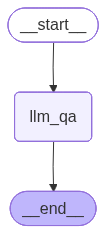

In [15]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())